# Rendimento Escolar: da fonte oficial ao Power BI

Este notebook demonstra o ciclo do Rendimento Escolar sem duplicar a logica dos scripts. O recorte e 2007-2023, por UF, etapas agregadas e rede publica. A saida analitica e `data/gold/fatos/fato_rendimento.parquet`.

## Ciclo e responsabilidade de cada etapa

1. **Raw:** arquivos oficiais anuais e imutaveis durante a execucao.
2. **Auditoria:** inspeciona estrutura, categorias e cobertura temporal.
3. **Bronze:** preserva e padroniza tecnicamente cada ano em Parquet.
4. **Silver:** harmoniza UF, etapa, rede e indicadores.
5. **Gold:** materializa a fato no grao `ANO + UF + ETAPA + REDE + INDICADOR`.
6. **Power BI:** calcula medidas como taxas medias conforme o contexto de filtro.

## Criterios de tratamento e linhagem

A quantidade de colunas diminui porque cada camada possui uma responsabilidade diferente:

| Camada | Criterio | Papel das colunas |
|---|---|---|
| Bronze | Preservar a leitura da planilha, inclusive metadados e colunas genericas `col_XXX` | Permitir reprocessamento e auditoria fiel da origem |
| Silver | Selecionar ano, 27 UFs, localizacao `Total` e o agregado oficial `Publico`/`Publica`; converter a planilha larga para o grao analitico | Manter colunas canonicas e colunas de linhagem |
| Gold | Selecionar somente as seis colunas necessarias ao modelo dimensional, sem recalcular taxas | Entregar uma fato enxuta ao Power BI |

`REDE` e `REDE_ORIGEM` nao representam duas medidas concorrentes. `REDE` recebe o valor canonico `PUBLICA`, usado para filtrar e relacionar dados de anos cujas fontes usam grafias diferentes. `REDE_ORIGEM` preserva literalmente a categoria encontrada na planilha e permite provar qual agregado foi selecionado. Da mesma forma, `LOCALIZACAO_ORIGEM`, `ARQUIVO_ORIGEM`, `LINHA_ORIGEM_BRONZE` e `COLUNA_ORIGEM` permitem rastrear cada valor Silver ate a celula de origem.

O projeto usa o agregado publico publicado pelo Inep. Nao calcula media simples entre Federal, Estadual e Municipal e nao usa um total geral que inclua a rede privada. Depois que a Silver e validada, as colunas de linhagem nao entram na Gold porque nao sao atributos analiticos necessarios ao dashboard; elas continuam preservadas na Silver para auditoria.

A selecao das colunas de valores e configurada por ano porque o posicionamento das taxas muda entre os arquivos. Cada linha publica-total por UF origina seis registros: duas etapas multiplicadas por tres indicadores. Assim, `17 anos x 27 UFs x 2 etapas x 3 indicadores = 2.754 registros`.

In [1]:
from pathlib import Path
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

DIRETORIO_ATUAL = Path.cwd().resolve()
ROOT = next((p for p in (DIRETORIO_ATUAL, *DIRETORIO_ATUAL.parents) if (p / 'src' / 'pipeline.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Nao foi possivel localizar a raiz do repositorio.')
print(f'Raiz do projeto: {ROOT}')

EXECUTAR_AUDITORIAS = False
EXECUTAR_PIPELINE_INDICADOR = False
pd.set_option('display.max_columns', 30)

Raiz do projeto: C:\portfolio-pipeline-dados-educacionais


In [2]:
AUDITORIAS = [
    'src/auditoria_rendimento/inspecionar_rendimento.py',
    'src/auditoria_rendimento/verificar_categorias_rendimento.py',
    'src/auditoria_rendimento/verificar_serie_publica_rendimento.py',
]
ETAPAS = [
    'src/bronze/rendimento/ingest_rendimento.py',
    'src/bronze/rendimento/validar_bronze_rendimento.py',
    'src/silver/rendimento/transformar_rendimento.py',
    'src/silver/rendimento/validar_silver_rendimento.py',
    'src/gold/rendimento/transformar_rendimento.py',
    'src/gold/rendimento/validar_fato_rendimento.py',
]

def executar(scripts):
    for script in scripts:
        print(f'\n>>> {script}')
        subprocess.run([sys.executable, script], cwd=ROOT, check=True)

print('Auditorias selecionadas:')
print(*AUDITORIAS, sep='\n- ')
print('\nEtapas do indicador:')
print(*ETAPAS, sep='\n- ')

Auditorias selecionadas:
src/auditoria_rendimento/inspecionar_rendimento.py
- src/auditoria_rendimento/verificar_categorias_rendimento.py
- src/auditoria_rendimento/verificar_serie_publica_rendimento.py

Etapas do indicador:
src/bronze/rendimento/ingest_rendimento.py
- src/bronze/rendimento/validar_bronze_rendimento.py
- src/silver/rendimento/transformar_rendimento.py
- src/silver/rendimento/validar_silver_rendimento.py
- src/gold/rendimento/transformar_rendimento.py
- src/gold/rendimento/validar_fato_rendimento.py


In [3]:
if EXECUTAR_AUDITORIAS:
    executar(AUDITORIAS)
else:
    print('Auditorias nao executadas. Altere EXECUTAR_AUDITORIAS para True quando necessario.')

if EXECUTAR_PIPELINE_INDICADOR:
    executar(ETAPAS)
else:
    print('Pipeline nao executado. Os artefatos existentes serao apenas lidos.')

Auditorias nao executadas. Altere EXECUTAR_AUDITORIAS para True quando necessario.
Pipeline nao executado. Os artefatos existentes serao apenas lidos.


## Evidencias por camada

A Raw e mostrada por inventario, sem carregar planilhas heterogeneas no notebook. Bronze, Silver e Gold sao lidas diretamente para evidenciar a evolucao do dado.

In [4]:
raw = sorted((ROOT / 'data/raw/rendimento').glob('*'))
bronze = sorted((ROOT / 'data/bronze/rendimento').glob('*.parquet'))
silver_path = ROOT / 'data/silver/rendimento/rendimento_2007_2023.parquet'
gold_path = ROOT / 'data/gold/fatos/fato_rendimento.parquet'
pd.DataFrame({
    'camada': ['Raw', 'Bronze', 'Silver', 'Gold'],
    'arquivos': [len(raw), len(bronze), int(silver_path.exists()), int(gold_path.exists())],
    'destino_principal': [str(raw[0].parent if raw else ''), str(bronze[0].parent if bronze else ''), str(silver_path), str(gold_path)],
})

,camada,arquivos,destino_principal
0,Raw,17,C:\portfolio-pipeline-dados-educacionais\data\...
1,Bronze,17,C:\portfolio-pipeline-dados-educacionais\data\...
2,Silver,1,C:\portfolio-pipeline-dados-educacionais\data\...
3,Gold,1,C:\portfolio-pipeline-dados-educacionais\data\...


In [5]:
amostra_bronze = pd.read_parquet(bronze[0])
silver = pd.read_parquet(silver_path)
gold = pd.read_parquet(gold_path)
display(amostra_bronze.head(3))
display(silver.head(3))
display(gold.head(3))
pd.DataFrame({
    'camada': ['Bronze (um ano)', 'Silver', 'Gold'],
    'linhas': [len(amostra_bronze), len(silver), len(gold)],
    'colunas': [len(amostra_bronze.columns), len(silver.columns), len(gold.columns)],
})

,_fonte,_sha256_arquivo,_arquivo_origem,_aba_origem,_ano_referencia,_indice_cabecalho_origem,_linha_origem,col_001,col_002,col_003,col_004,col_005,col_006,col_007,col_008,...,col_045,col_046,col_047,col_048,col_049,col_050,col_051,col_052,col_053,col_054,col_055,col_056,col_057,col_058,col_059
0,RENDIMENTO,492e0acfc54f8de363416d315042cb96def1392f632c03...,TX RENDIMENTO UFS 2007.xls,REND. POR UF,2007,6,1,<NA>,Ministério da Educação,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,RENDIMENTO,492e0acfc54f8de363416d315042cb96def1392f632c03...,TX RENDIMENTO UFS 2007.xls,REND. POR UF,2007,6,2,<NA>,Instituto Nacional de Est...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,RENDIMENTO,492e0acfc54f8de363416d315042cb96def1392f632c03...,TX RENDIMENTO UFS 2007.xls,REND. POR UF,2007,6,4,Taxas de...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


,ANO,UF,ETAPA,REDE,INDICADOR,VALOR,REDE_ORIGEM,LOCALIZACAO_ORIGEM,ARQUIVO_ORIGEM,LINHA_ORIGEM_BRONZE,COLUNA_ORIGEM
0,2007,AC,ANOS_INICIAIS,PUBLICA,APROVACAO,78.3,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_015
1,2007,AC,ANOS_INICIAIS,PUBLICA,REPROVACAO,15.2,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_033
2,2007,AC,ANOS_INICIAIS,PUBLICA,ABANDONO,6.5,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_051


,ANO,UF,ETAPA,REDE,INDICADOR,VALOR
0,2007,AC,ANOS_FINAIS,PUBLICA,ABANDONO,6.8
1,2007,AC,ANOS_FINAIS,PUBLICA,APROVACAO,85.5
2,2007,AC,ANOS_FINAIS,PUBLICA,REPROVACAO,7.7


,camada,linhas,colunas
0,Bronze (um ano),480,66
1,Silver,2754,11
2,Gold,2754,6


### Evidencia da padronizacao

A tabela seguinte mostra as categorias realmente encontradas nos arquivos e sua correspondencia com `REDE = PUBLICA`. O exemplo de linhagem mostra que o valor analitico continua ligado ao arquivo, linha e coluna de onde foi extraido.

In [6]:
padronizacao_rede = (
    silver.groupby(['REDE_ORIGEM', 'LOCALIZACAO_ORIGEM', 'REDE'], as_index=False)
    .agg(ANO_INICIAL=('ANO', 'min'), ANO_FINAL=('ANO', 'max'), REGISTROS=('ANO', 'size'))
)
display(padronizacao_rede)

colunas_linhagem = [
    'ANO', 'UF', 'ETAPA', 'INDICADOR', 'VALOR', 'REDE', 'REDE_ORIGEM',
    'LOCALIZACAO_ORIGEM', 'ARQUIVO_ORIGEM', 'LINHA_ORIGEM_BRONZE', 'COLUNA_ORIGEM',
]
display(silver.loc[:, colunas_linhagem].head(6))

pd.DataFrame({
    'Silver_preserva_para_auditoria': [', '.join(c for c in silver.columns if c not in gold.columns)],
    'Gold_entrega_ao_BI': [', '.join(gold.columns)],
})

,REDE_ORIGEM,LOCALIZACAO_ORIGEM,REDE,ANO_INICIAL,ANO_FINAL,REGISTROS
0,Publico,Total,PUBLICA,2007,2014,1296
1,Pública,Total,PUBLICA,2015,2023,1458


,ANO,UF,ETAPA,INDICADOR,VALOR,REDE,REDE_ORIGEM,LOCALIZACAO_ORIGEM,ARQUIVO_ORIGEM,LINHA_ORIGEM_BRONZE,COLUNA_ORIGEM
0,2007,AC,ANOS_INICIAIS,APROVACAO,78.3,PUBLICA,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_015
1,2007,AC,ANOS_INICIAIS,REPROVACAO,15.2,PUBLICA,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_033
2,2007,AC,ANOS_INICIAIS,ABANDONO,6.5,PUBLICA,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_051
3,2007,AC,ANOS_FINAIS,APROVACAO,85.5,PUBLICA,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_016
4,2007,AC,ANOS_FINAIS,REPROVACAO,7.7,PUBLICA,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_034
5,2007,AC,ANOS_FINAIS,ABANDONO,6.8,PUBLICA,Publico,Total,TX RENDIMENTO UFS 2007.xls,36,col_052


,Silver_preserva_para_auditoria,Gold_entrega_ao_BI
0,"REDE_ORIGEM, LOCALIZACAO_ORIGEM, ARQUIVO_ORIGE...","ANO, UF, ETAPA, REDE, INDICADOR, VALOR"


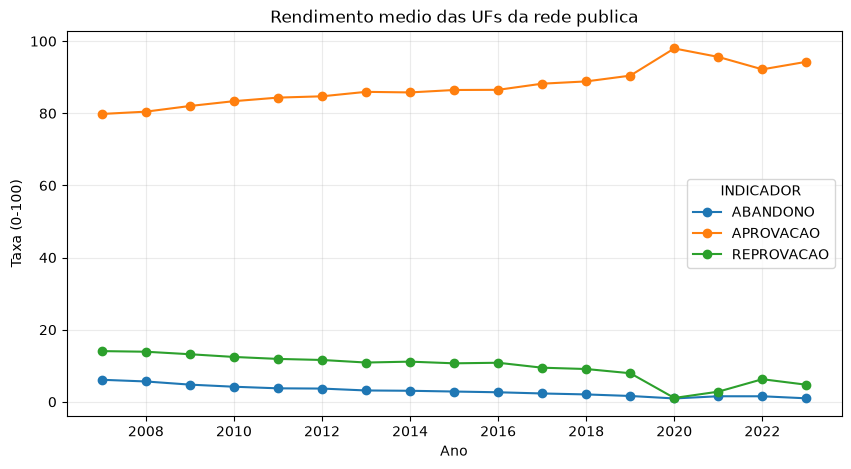

In [7]:
resumo = (gold.groupby(['ANO', 'INDICADOR'], as_index=False)['VALOR'].mean())
grafico = resumo.pivot(index='ANO', columns='INDICADOR', values='VALOR')
ax = grafico.plot(figsize=(10, 5), marker='o')
ax.set(title='Rendimento medio das UFs da rede publica', xlabel='Ano', ylabel='Taxa (0-100)')
ax.grid(alpha=0.25)
plt.show()

## Disponibilizacao para o BI

O Power BI consome a fato Gold e as dimensoes compartilhadas em `data/gold/dimensoes`. Para reconstruir e validar o modelo completo, execute `python src/pipeline.py full`. A media acima e uma demonstracao descritiva e nao substitui as medidas DAX nem implica causalidade.